# Multiple run model-based hypervolume

**MORBO and qNParEGO: mean hypervolume across 10 independent runs**, with shaded areas showing **mean ? one sample standard deviation** (`ddof=1`), not confidence intervals.

Gravity heterogeneity, request-rate heterogeneity, and synchronization are shown for the holistic and Cheetah reductionist approaches, with separate RTS and STR figures. Step 0 is the initial Sobol design; the remaining checkpoints are optimization steps 2, 4, ..., 20. Each run uses 8 initial sequences and 20 batches of 4 candidates.

Data are read from `../Model-based experiments/model_based_results.pkl`. The notebook only validates and plots saved results. Two simulated objective realizations per candidate are distinct from the ten independent optimization runs (seeds 42?51).

The plotted values are the saved normalized RTS/STR hypervolume estimates, using 128 scalarization directions and fixed reference costs shared by both algorithms within each approach. No smoothing or cumulative maximum is applied. Shading describes variation across runs; these are not held-out evaluations.

The earlier [single-run notebook](<Model-based hypervolume results.ipynb>) is preserved.

In [1]:
from pathlib import Path
from copy import deepcopy
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'Model-based experiments' / 'model_based_results.pkl').is_file()), None)
if root is None:
    raise FileNotFoundError('Open this notebook from the Cosmic Octopi project.')
result_path = root / 'Model-based experiments' / 'model_based_results.pkl'
with result_path.open('rb') as file:
    bundle = pickle.load(file)
if bundle.get('kind') != 'model_based_suite' or not bundle.get('complete'):
    raise ValueError('The model-based suite must be complete before plotting.')
config = bundle['setup']
n_runs = config['n_independent_runs']
algorithms = ('MORBO', 'qNParEGO')
approaches = ('holistic', 'reductionist')
experiments = ('gravity', 'heterogeneity', 'synchronization')
formulations = ('RTS', 'STR')
seeds = [config['base_seed'] + i * config['seed_increment'] for i in range(n_runs)]
if n_runs != 10 or len(set(seeds)) != n_runs:
    raise ValueError('Expected ten distinct independent-run seeds.')
expected_keys = {f'run_{i:02d}_seed_{seed}/{algorithm}/{approach}/{experiment}'
                 for i, seed in enumerate(seeds, 1) for algorithm in algorithms
                 for approach in approaches for experiment in experiments}
if set(bundle['experiments']) != expected_keys:
    raise ValueError('Missing or unexpected experiment records.')
hp0 = config['hyperparameters']['MORBO']
for name in ('n_initial_points', 'batch_size', 'n_iterations', 'hypervolume_checkpoint_every',
             'hypervolume_directions', 'direction_endpoint_epsilon', 'hypervolume_direction_rule'):
    if config['hyperparameters']['qNParEGO'][name] != hp0[name]:
        raise ValueError(f'Algorithms differ in {name}.')
checkpoints = np.array(sorted({0, hp0['n_iterations'],
    *range(hp0['hypervolume_checkpoint_every'], hp0['n_iterations']+1,
           hp0['hypervolume_checkpoint_every'])}))
histories = {}
for i, seed in enumerate(seeds, 1):
    for algorithm in algorithms:
        for approach in approaches:
            for experiment in experiments:
                key = f'run_{i:02d}_seed_{seed}/{algorithm}/{approach}/{experiment}'
                record = bundle['experiments'][key]
                if (not record['complete'] or record['independent_run'] != i
                        or record['seed'] != seed or record['algorithm'] != algorithm
                        or record['approach'] != approach or record['experiment'] != experiment):
                    raise ValueError(f'Incomplete or mislabeled record: {key}')
                expected_setup = deepcopy(config['common_setup'])
                expected_setup.update(deepcopy(config['approaches'][approach]))
                expected_setup.update(deepcopy(config['experiments'][experiment]))
                expected_setup['seed'] = seed
                if experiment == 'gravity':
                    expected_setup['gravity_variances'] = list(expected_setup['sweep']['values'])
                if record['setup'] != expected_setup or record['suite_setup'] != config:
                    raise ValueError(f'Inconsistent settings: {key}')
                hp = {**config['hyperparameters'][algorithm],
                      'dimension': expected_setup[approach]['horizon']}
                if record['hyperparameters'] != hp:
                    raise ValueError(f'Inconsistent optimizer settings: {key}')
                for name, digest in record['source_sha256'].items():
                    if bundle['source_sha256'].get(name) != digest:
                        raise ValueError(f'Inconsistent source provenance: {key}/{name}')
                for name, matrix in config['Xi_matrices'].items():
                    np.testing.assert_array_equal(record['xi_matrices'][name], matrix)
                sweep = expected_setup['sweep']
                expected_curves = {f"{form}/{sweep['parameter']}={level:g}"
                                   for form in formulations for level in sweep['values']}
                if set(record['runs']) != expected_curves:
                    raise ValueError(f'Missing curves: {key}')
                for form in formulations:
                    for level in sweep['values']:
                        run = record['runs'][f"{form}/{sweep['parameter']}={level:g}"]
                        if (run['formulation'] != form
                                or run.get('sweep_value', run.get('gravity_variance')) != level):
                            raise ValueError(f'Mislabeled curve: {key}')
                        if (len(run['direction_angle_history']) != hp['n_iterations']
                                or run['pending_X'] is not None or run['pending_angle'] is not None):
                            raise ValueError(f'Unfinished optimization: {key}')
                        counts = np.asarray(run['evaluation_counts'])
                        np.testing.assert_array_equal(counts,
                            hp['n_initial_points'] + checkpoints * hp['batch_size'])
                        expected_n = hp['n_initial_points'] + hp['n_iterations'] * hp['batch_size']
                        if (run['X_unit'].shape != (expected_n, hp['dimension'])
                                or run['cost_realizations'].shape !=
                                (expected_n, expected_setup['n_realizations_per_candidate'], 2)
                                or not np.isfinite(run['cost_realizations']).all()):
                            raise ValueError(f'Incomplete candidate data: {key}')
                        values = np.asarray(run['hypervolume_history'], float)
                        if (values.shape != checkpoints.shape or not np.isfinite(values).all()
                                or (values < 0).any()):
                            raise ValueError(f'Invalid hypervolume history: {key}')
                        group = (approach, experiment, form, algorithm, level)
                        histories.setdefault(group, []).append(values)
statistics = {}
for key, values in histories.items():
    samples = np.stack(values)
    if samples.shape != (n_runs, len(checkpoints)):
        raise ValueError(f'Unaligned histories: {key}')
    statistics[key] = {'samples': samples, 'mean': samples.mean(axis=0),
                       'std': samples.std(axis=0, ddof=1)}
assert len(statistics) == 48
display(Markdown(f'Verified **{n_runs} independent runs**, **{len(expected_keys)} experiments**, '
                 f'and **{len(statistics)*n_runs} optimization histories**. '
                 f'Checkpoints: **{", ".join(map(str, checkpoints))}**.'))
reference_rows = ['| Approach | Sequence horizon | Overhead reference (KiB) | Instability reference |',
                  '|---|---:|---:|---:|']
for approach in approaches:
    a = config['approaches'][approach]
    reference_rows.append(f"| {approach} | {a[approach]['horizon']} | "
                          f"{a['reference_costs'][0]:,.6f} | {a['reference_costs'][1]:g} |")
display(Markdown('\n'.join(reference_rows)))


Verified **10 independent runs**, **120 experiments**, and **480 optimization histories**. Checkpoints: **0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20**.

| Approach | Sequence horizon | Overhead reference (KiB) | Instability reference |
|---|---:|---:|---:|
| holistic | 100 | 2,200,000.000000 | 310 |
| reductionist | 50 | 90,497.578125 | 85 |

In [2]:
def plot_multiple_runs(approach, experiment, formulation):
    sweep = config['experiments'][experiment]['sweep']
    groups = [statistics[(approach, experiment, form, algorithm, level)]
              for form in formulations for algorithm in algorithms for level in sweep['values']]
    lower = min(np.min(g['mean']-g['std']) for g in groups)
    upper = max(np.max(g['mean']+g['std']) for g in groups)
    padding = max(.005, .08*(upper-lower))
    fig, ax = plt.subplots(figsize=(6, 5))
    for color, level in zip(('#1f77b4', '#ff7f0e'), sweep['values']):
        for algorithm, linestyle, marker in (('MORBO', '-', 'o'), ('qNParEGO', '--', 's')):
            s = statistics[(approach, experiment, formulation, algorithm, level)]
            label = algorithm + r', $\gamma_{\mathrm{' + sweep['symbol'] + '}} = ' + f'{level:g}' + '$'
            ax.fill_between(checkpoints, s['mean']-s['std'], s['mean']+s['std'],
                            color=color, alpha=.13, linewidth=0)
            ax.plot(checkpoints, s['mean'], color=color, linestyle=linestyle, marker=marker,
                    linewidth=2, markersize=4, label=label)
    ax.set_xlabel('Optimization step', fontsize=14)
    ax.set_ylabel('Normalized hypervolume', fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xticks(checkpoints)
    ax.set_xlim(checkpoints[0], checkpoints[-1])
    ax.set_ylim(lower-padding, upper+padding)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.grid(False)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


## Gravity heterogeneity

$\gamma_{\mathrm{grav}}=1$ versus $5$, with synchronization 1 and request-rate heterogeneity 0.5.

### Holistic / RTS

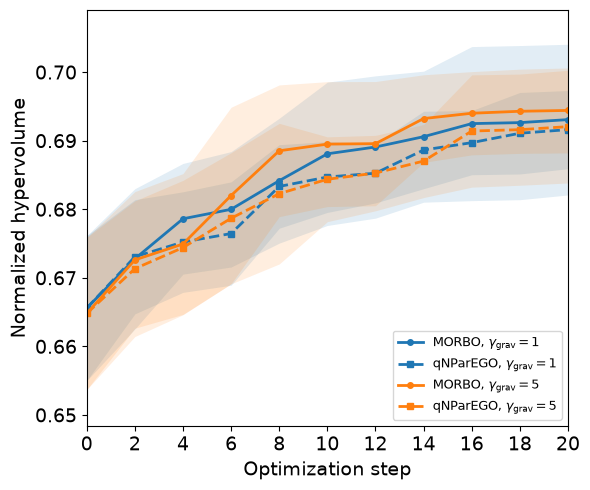

In [3]:
plot_multiple_runs("holistic", "gravity", "RTS")

### Holistic / STR

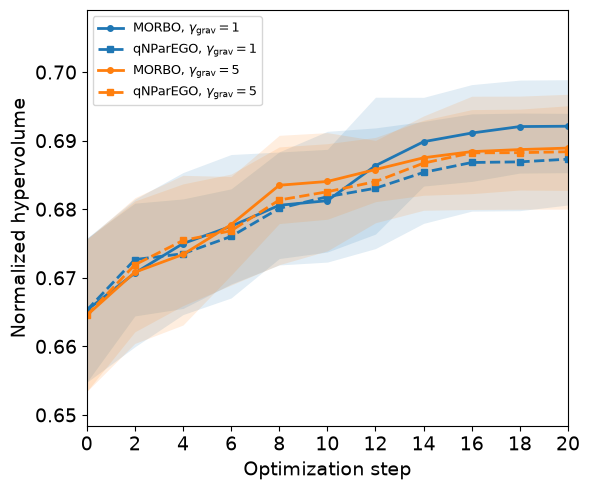

In [4]:
plot_multiple_runs("holistic", "gravity", "STR")

### Cheetah reductionist / RTS

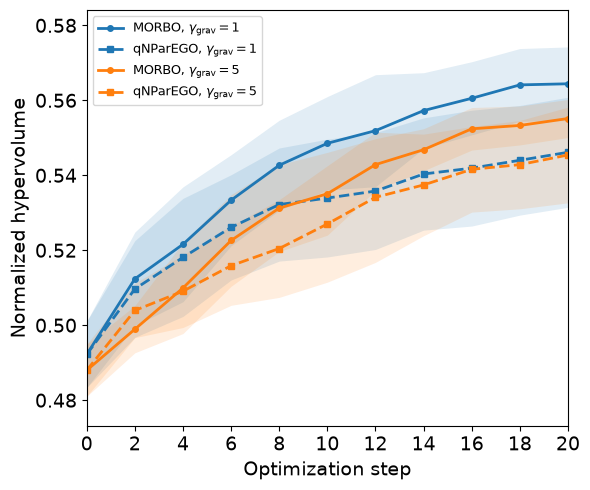

In [5]:
plot_multiple_runs("reductionist", "gravity", "RTS")

### Cheetah reductionist / STR

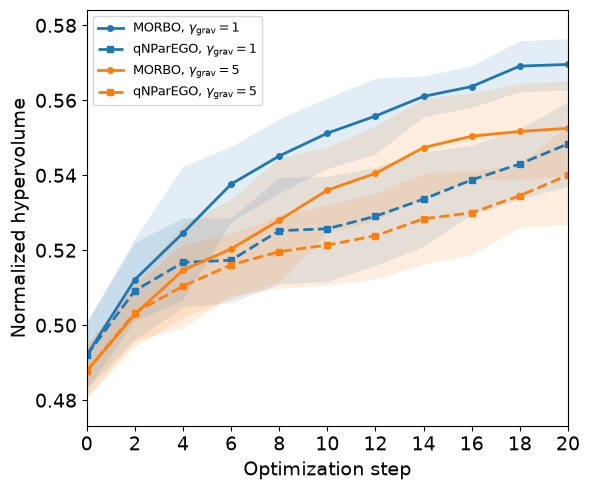

In [6]:
plot_multiple_runs("reductionist", "gravity", "STR")

## Request-rate heterogeneity

$\gamma_{\mathrm{heter}}=0.1$ versus $0.8$, with synchronization 1 and gravity variance 0.1.

### Holistic / RTS

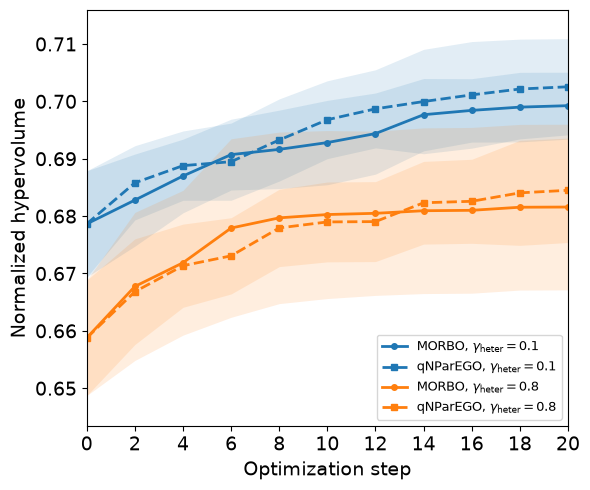

In [7]:
plot_multiple_runs("holistic", "heterogeneity", "RTS")

### Holistic / STR

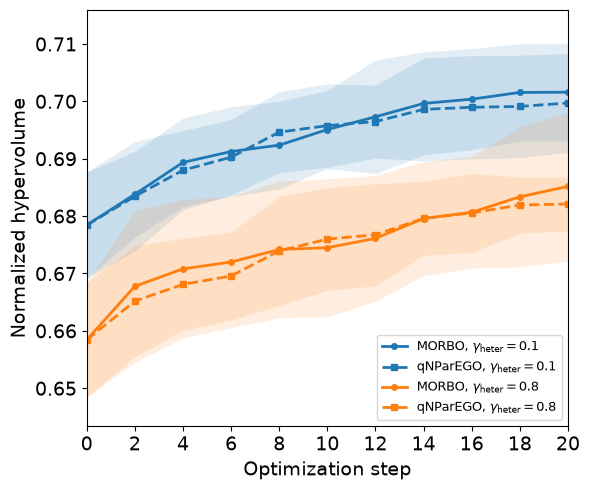

In [8]:
plot_multiple_runs("holistic", "heterogeneity", "STR")

### Cheetah reductionist / RTS

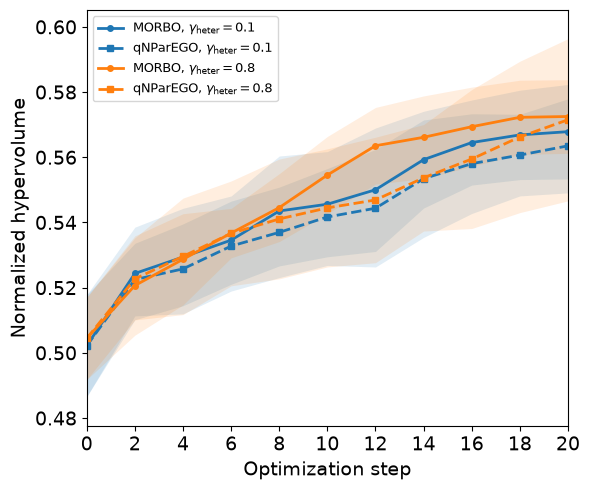

In [9]:
plot_multiple_runs("reductionist", "heterogeneity", "RTS")

### Cheetah reductionist / STR

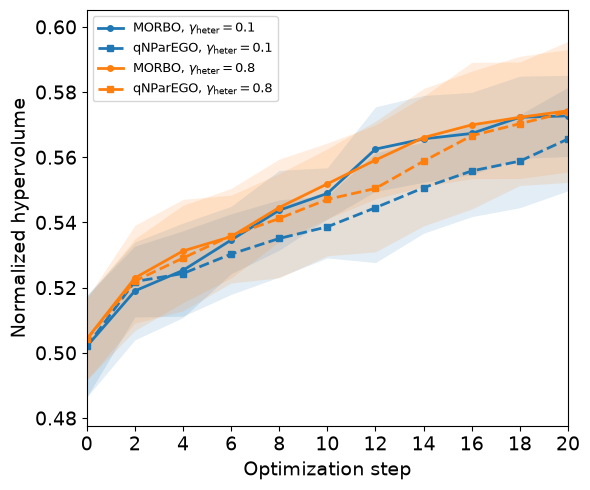

In [10]:
plot_multiple_runs("reductionist", "heterogeneity", "STR")

## Synchronization

$\gamma_{\mathrm{sync}}=1$ versus $0.8$, with gravity variance 0.1 and request-rate heterogeneity 0.5.

### Holistic / RTS

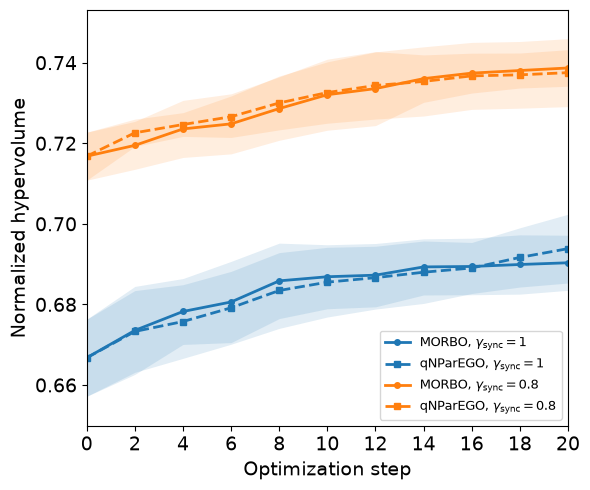

In [11]:
plot_multiple_runs("holistic", "synchronization", "RTS")

### Holistic / STR

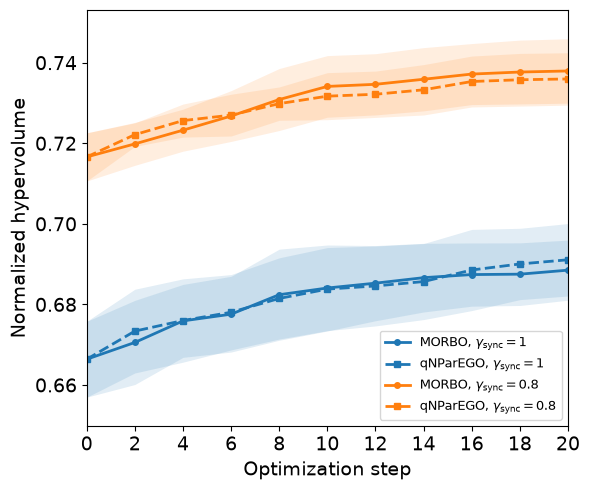

In [12]:
plot_multiple_runs("holistic", "synchronization", "STR")

### Cheetah reductionist / RTS

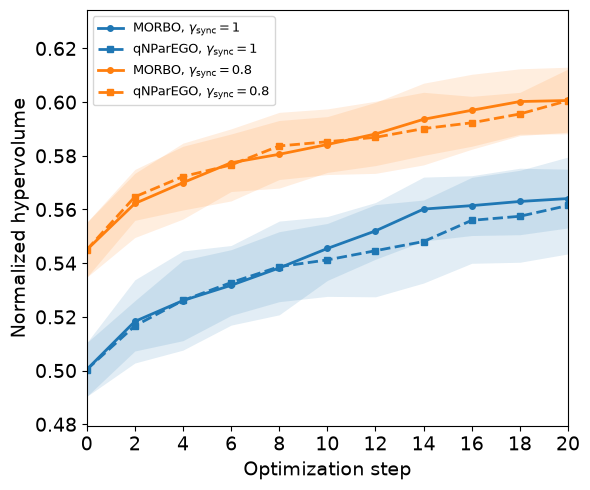

In [13]:
plot_multiple_runs("reductionist", "synchronization", "RTS")

### Cheetah reductionist / STR

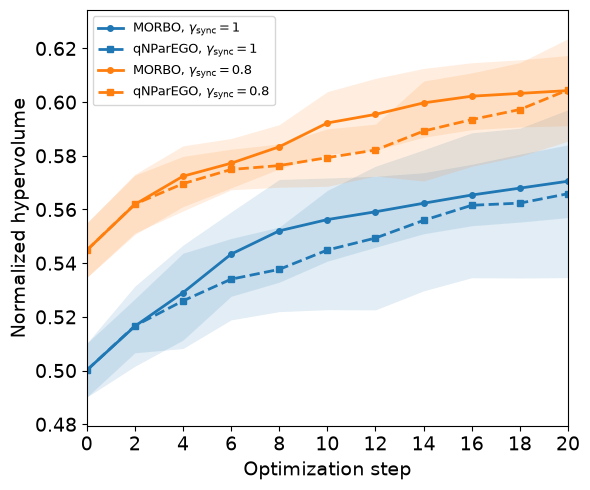

In [14]:
plot_multiple_runs("reductionist", "synchronization", "STR")

## Final hypervolume statistics

Mean and sample standard deviation across ten independent runs at optimization step 20.

In [15]:
rows = ["| Experiment | Approach | Algorithm | Formulation | Sweep value | Runs | Mean final HV | SD |",
        "|---|---|---|---|---:|---:|---:|---:|"]
for experiment in experiments:
    for approach in approaches:
        for algorithm in algorithms:
            for form in formulations:
                for level in config["experiments"][experiment]["sweep"]["values"]:
                    values = statistics[(approach, experiment, form, algorithm, level)]
                    rows.append(f"| {experiment} | {approach} | {algorithm} | {form} | {level:g} | "
                                f"{n_runs} | {values['mean'][-1]:.6f} | {values['std'][-1]:.6f} |")
display(Markdown("\n".join(rows)))


| Experiment | Approach | Algorithm | Formulation | Sweep value | Runs | Mean final HV | SD |
|---|---|---|---|---:|---:|---:|---:|
| gravity | holistic | MORBO | RTS | 1 | 10 | 0.693067 | 0.010988 |
| gravity | holistic | MORBO | RTS | 5 | 10 | 0.694406 | 0.006194 |
| gravity | holistic | MORBO | STR | 1 | 10 | 0.692104 | 0.006780 |
| gravity | holistic | MORBO | STR | 5 | 10 | 0.688916 | 0.006173 |
| gravity | holistic | qNParEGO | RTS | 1 | 10 | 0.691610 | 0.005701 |
| gravity | holistic | qNParEGO | RTS | 5 | 10 | 0.692041 | 0.008216 |
| gravity | holistic | qNParEGO | STR | 1 | 10 | 0.687299 | 0.006681 |
| gravity | holistic | qNParEGO | STR | 5 | 10 | 0.688385 | 0.008376 |
| gravity | reductionist | MORBO | RTS | 1 | 10 | 0.564411 | 0.009825 |
| gravity | reductionist | MORBO | RTS | 5 | 10 | 0.555145 | 0.005072 |
| gravity | reductionist | MORBO | STR | 1 | 10 | 0.569562 | 0.006882 |
| gravity | reductionist | MORBO | STR | 5 | 10 | 0.552534 | 0.012660 |
| gravity | reductionist | qNParEGO | RTS | 1 | 10 | 0.546136 | 0.014684 |
| gravity | reductionist | qNParEGO | RTS | 5 | 10 | 0.545417 | 0.012766 |
| gravity | reductionist | qNParEGO | STR | 1 | 10 | 0.548386 | 0.011243 |
| gravity | reductionist | qNParEGO | STR | 5 | 10 | 0.540049 | 0.013200 |
| heterogeneity | holistic | MORBO | RTS | 0.1 | 10 | 0.699247 | 0.005835 |
| heterogeneity | holistic | MORBO | RTS | 0.8 | 10 | 0.681578 | 0.014436 |
| heterogeneity | holistic | MORBO | STR | 0.1 | 10 | 0.701594 | 0.008470 |
| heterogeneity | holistic | MORBO | STR | 0.8 | 10 | 0.685178 | 0.012973 |
| heterogeneity | holistic | qNParEGO | RTS | 0.1 | 10 | 0.702541 | 0.008382 |
| heterogeneity | holistic | qNParEGO | RTS | 0.8 | 10 | 0.684497 | 0.009100 |
| heterogeneity | holistic | qNParEGO | STR | 0.1 | 10 | 0.699709 | 0.008607 |
| heterogeneity | holistic | qNParEGO | STR | 0.8 | 10 | 0.682110 | 0.004714 |
| heterogeneity | reductionist | MORBO | RTS | 0.1 | 10 | 0.567841 | 0.014483 |
| heterogeneity | reductionist | MORBO | RTS | 0.8 | 10 | 0.572495 | 0.011293 |
| heterogeneity | reductionist | MORBO | STR | 0.1 | 10 | 0.572679 | 0.012453 |
| heterogeneity | reductionist | MORBO | STR | 0.8 | 10 | 0.574265 | 0.018797 |
| heterogeneity | reductionist | qNParEGO | RTS | 0.1 | 10 | 0.563497 | 0.014427 |
| heterogeneity | reductionist | qNParEGO | RTS | 0.8 | 10 | 0.571498 | 0.024872 |
| heterogeneity | reductionist | qNParEGO | STR | 0.1 | 10 | 0.565596 | 0.015867 |
| heterogeneity | reductionist | qNParEGO | STR | 0.8 | 10 | 0.573902 | 0.021611 |
| synchronization | holistic | MORBO | RTS | 1 | 10 | 0.690327 | 0.006836 |
| synchronization | holistic | MORBO | RTS | 0.8 | 10 | 0.738683 | 0.004542 |
| synchronization | holistic | MORBO | STR | 1 | 10 | 0.688495 | 0.007457 |
| synchronization | holistic | MORBO | STR | 0.8 | 10 | 0.737937 | 0.007993 |
| synchronization | holistic | qNParEGO | RTS | 1 | 10 | 0.693835 | 0.008534 |
| synchronization | holistic | qNParEGO | RTS | 0.8 | 10 | 0.737521 | 0.008432 |
| synchronization | holistic | qNParEGO | STR | 1 | 10 | 0.691071 | 0.008989 |
| synchronization | holistic | qNParEGO | STR | 0.8 | 10 | 0.735958 | 0.006504 |
| synchronization | reductionist | MORBO | RTS | 1 | 10 | 0.564078 | 0.010943 |
| synchronization | reductionist | MORBO | RTS | 0.8 | 10 | 0.600605 | 0.012404 |
| synchronization | reductionist | MORBO | STR | 1 | 10 | 0.570530 | 0.013538 |
| synchronization | reductionist | MORBO | STR | 0.8 | 10 | 0.604295 | 0.013084 |
| synchronization | reductionist | qNParEGO | RTS | 1 | 10 | 0.561497 | 0.018034 |
| synchronization | reductionist | qNParEGO | RTS | 0.8 | 10 | 0.600566 | 0.011759 |
| synchronization | reductionist | qNParEGO | STR | 1 | 10 | 0.565885 | 0.031264 |
| synchronization | reductionist | qNParEGO | STR | 0.8 | 10 | 0.604543 | 0.019093 |